In [20]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use(hep.style.CMS)

# ----------------------------------------------------
# Constants (MeV)
# ----------------------------------------------------
m_pi = 139.57
m_mu = 105.66

# Muon momentum and energy in pion rest frame
p_mu_star = (m_pi**2 - m_mu**2) / (2 * m_pi)
E_mu_star = (m_pi**2 + m_mu**2) / (2 * m_pi)

print(f"p_mu* = {p_mu_star:.2f} MeV/c")
print(f"E_mu* = {E_mu_star:.2f} MeV")

# ----------------------------------------------------
# Function to calculate muon momentum in lab frame
# ----------------------------------------------------
def muon_momentum_lab(p_pi, theta_star):
    """
    p_pi       : pion momentum (MeV/c)
    theta_star : decay angle in pion rest frame (rad)
    """

    E_pi = np.sqrt(p_pi**2 + m_pi**2)

    beta = p_pi / E_pi
    gamma = E_pi / m_pi

    # Lorentz transformed components
    p_parallel = gamma * (
        p_mu_star * np.cos(theta_star)
        + beta * E_mu_star
    )

    p_perp = p_mu_star * np.sin(theta_star)

    return np.sqrt(p_parallel**2 + p_perp**2)

# ----------------------------------------------------
# Angle range
# ----------------------------------------------------
theta = np.linspace(0, np.pi, 1000)

# Pion momenta defining the acceptance window
pion_momenta = [190, 270, 300, 360]

p_mu* = 29.79 MeV/c
E_mu* = 109.78 MeV


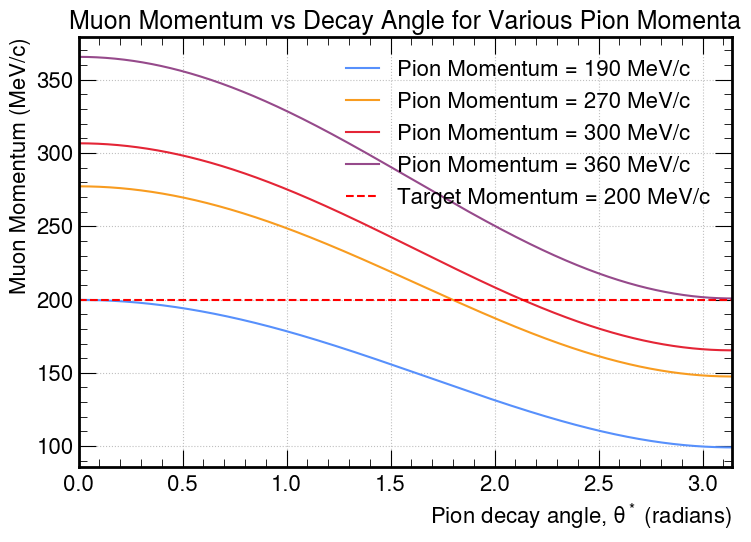

In [21]:
# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# define the fontsize used in the plot
fs = 16

for p_pi in pion_momenta:
    p_mu = muon_momentum_lab(p_pi, theta)

    plt.plot(
        theta,
        p_mu,
        label=f'Pion Momentum = {p_pi:.0f} MeV/c'
    )

# Target momentum
plt.axhline(
    200,
    linestyle='--',
    color='red',
    label='Target Momentum = 200 MeV/c'
)

ax.tick_params(axis='both', labelsize = fs)
plt.xlabel(r'Pion decay angle, $\theta^*$ (radians)', fontsize = fs)
plt.ylabel('Muon Momentum (MeV/c)', fontsize = fs)
plt.title('Muon Momentum vs Decay Angle for Various Pion Momenta', fontsize = 18)
plt.xlim(0, np.pi)
plt.grid(True)
plt.legend(fontsize = 16)

plt.tight_layout()
plt.show()